import pandas as pd
data = pd.read_csv('C:\\Users\\amish\\Downloads\\fraud ml\\creditcard.csv')  # Adjust path as needed
print(data.head())
print(data.info())


In [3]:
print(data.isnull().sum())


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [4]:
from sklearn.preprocessing import StandardScaler

data['Amount'] = StandardScaler().fit_transform(data['Amount'].values.reshape(-1, 1))
data['Time'] = StandardScaler().fit_transform(data['Time'].values.reshape(-1, 1))


In [5]:
X = data.drop(['Class'], axis=1)
y = data['Class']


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9995611109160493
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [9]:
import joblib

joblib.dump(model, 'fraud_detection_model.pkl')


['fraud_detection_model.pkl']

In [11]:
import os
print(os.getcwd())  # Prints the current directory


C:\Users\amish\fraud ml


In [3]:
import joblib

# Load the trained model
model = joblib.load('fraud_detection_model.pkl')


In [7]:
print(type(model))  # Check the type of the loaded model


<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [9]:
# Remove 'Class' from the feature names
feature_names = ["Time", "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9", "V10", "V11", 
                 "V12", "V13", "V14", "V15", "V16", "V17", "V18", "V19", "V20", "V21", "V22", "V23", 
                 "V24", "V25", "V26", "V27", "V28", "Amount"]

# Check the size of the feature_importances array
feature_importances = model.feature_importances_

# Check if the number of features matches
print("Number of features in model:", len(feature_importances))
print("Number of feature names:", len(feature_names))

# Map feature names with their importances
feature_importance_dict = {feature_names[i]: feature_importances[i] for i in range(len(feature_names))}

# Print feature importances
print("Feature Importances with names:", feature_importance_dict)



Number of features in model: 30
Number of feature names: 30
Feature Importances with names: {'Time': np.float64(0.011628914905423234), 'V1': np.float64(0.013598134523795349), 'V2': np.float64(0.01425397442814942), 'V3': np.float64(0.01719420201598434), 'V4': np.float64(0.026812556168203456), 'V5': np.float64(0.011040785731577425), 'V6': np.float64(0.012791345437204501), 'V7': np.float64(0.029772073353040097), 'V8': np.float64(0.012555859157792571), 'V9': np.float64(0.03404052717010789), 'V10': np.float64(0.08116569710492948), 'V11': np.float64(0.05792690156534205), 'V12': np.float64(0.13480040423441375), 'V13': np.float64(0.009855151037733587), 'V14': np.float64(0.1246076726778733), 'V15': np.float64(0.012203198787408918), 'V16': np.float64(0.07463539186534246), 'V17': np.float64(0.15752608772036938), 'V18': np.float64(0.02832215144610303), 'V19': np.float64(0.013544622133580908), 'V20': np.float64(0.014002637157095824), 'V21': np.float64(0.018451865326066335), 'V22': np.float64(0.0109

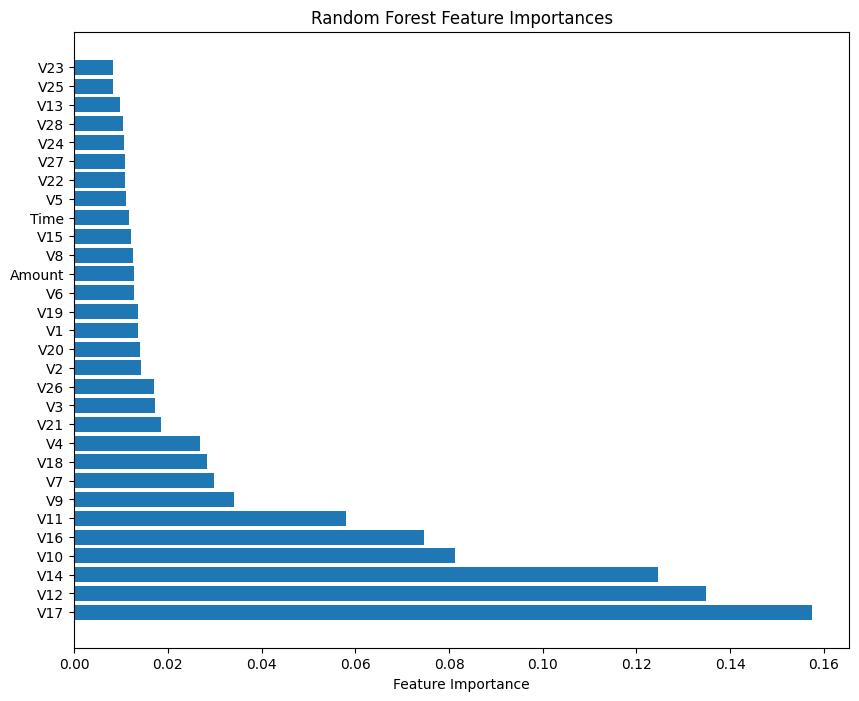

In [10]:
import matplotlib.pyplot as plt

# Sort feature importances
sorted_idx = feature_importance_dict.values()
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Plot the feature importances
features, importances = zip(*sorted_features)
plt.figure(figsize=(10, 8))
plt.barh(features, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.show()


In [11]:
input_data = {
    "Time": [1000],  # Example value for the Time feature
    "V1": [0.1],     # Example value for V1
    "V2": [0.2],     # Example value for V2
    "V3": [0.3],     # Example value for V3
    "V4": [0.4],     # Example value for V4
    "V5": [0.5],     # Example value for V5
    "V6": [0.6],     # Example value for V6
    "V7": [0.7],     # Example value for V7
    "V8": [0.8],     # Example value for V8
    "V9": [0.9],     # Example value for V9
    "V10": [1.0],    # Example value for V10
    "V11": [1.1],    # Example value for V11
    "V12": [1.2],    # Example value for V12
    "V13": [1.3],    # Example value for V13
    "V14": [1.4],    # Example value for V14
    "V15": [1.5],    # Example value for V15
    "V16": [1.6],    # Example value for V16
    "V17": [1.7],    # Example value for V17
    "V18": [1.8],    # Example value for V18
    "V19": [1.9],    # Example value for V19
    "V20": [2.0],    # Example value for V20
    "V21": [2.1],    # Example value for V21
    "V22": [2.2],    # Example value for V22
    "V23": [2.3],    # Example value for V23
    "V24": [2.4],    # Example value for V24
    "V25": [2.5],    # Example value for V25
    "V26": [2.6],    # Example value for V26
    "V27": [2.7],    # Example value for V27
    "V28": [2.8],    # Example value for V28
    "Amount": [500]  # Example value for the Amount feature
}


In [12]:
import pandas as pd

# Convert the input data dictionary to a DataFrame
df_input = pd.DataFrame(input_data)

# Verify the DataFrame structure
print(df_input.head())  # This will print the first row of the DataFrame to check if it looks correct


   Time   V1   V2   V3   V4   V5   V6   V7   V8   V9  ...  V20  V21  V22  V23  \
0  1000  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  2.0  2.1  2.2  2.3   

   V24  V25  V26  V27  V28  Amount  
0  2.4  2.5  2.6  2.7  2.8     500  

[1 rows x 30 columns]


In [13]:
print("Input DataFrame Columns:", df_input.columns.tolist())


Input DataFrame Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [14]:
# Load your model (if not already loaded)
import joblib
model = joblib.load('fraud_detection_model.pkl')

# Make the prediction
prediction = model.predict(df_input)

# Print the result
print("Prediction result:", prediction)


Prediction result: [0]


In [15]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

# Load the trained model
model = joblib.load('fraud_detection_model.pkl')

@app.route('/predict', methods=['POST'])
def predict():
    if not request.is_json:
        return jsonify({"error": "Request must be in JSON format"}), 400

    data = request.get_json()
    if not data:
        return jsonify({"error": "No data provided"}), 400

    try:
        df = pd.DataFrame([data])
        prediction = model.predict(df)
        return jsonify({'predictions': prediction.tolist()})

    except Exception as e:
        return jsonify({"error": str(e)}), 500

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.1.2:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

C:\Users\amish\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
